# The Fourth Circle: Neural Networks, Part Two 
## Convolutional Neural Networks VII: Inception-ResNet, ResNeXt

<br/>
Jiří Fejlek

2026-03-13
<br/>

In this small project, we will introduce two neural networks inspired by the original ResNet[[1](#1)]: Inception-ResNet [[2](#2)] and ResNeXt [[3](#3)], both from 2016.

## Table of Contents

- [Inception-ResNet](#Inception-ResNet)
- [ResNeXt](#resnext)
- [References](#references)

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

import torchvision
import torch

from torch import nn
from torch.utils.data import DataLoader

np.set_printoptions(legacy='1.25')

In [2]:
cuda_device = torch.device('cuda')
torch.cuda.get_device_name(cuda_device)

'NVIDIA GeForce RTX 4070 Ti'

In [3]:
def layer_summary(nn_model, X_shape):
    X = torch.randn(*X_shape)
    for layer in nn_model.net_stack:
        X = layer(X)
        print(layer.__class__.__name__, 'output shape:\t', X.shape)

In [4]:
def init_weights_he(model):
    if isinstance(model, nn.Linear):
        nn.init.kaiming_normal_(model.weight, nonlinearity = 'relu') 
        nn.init.constant_(model.bias, 0) 
    if isinstance(model, nn.Conv2d):
        nn.init.kaiming_normal_(model.weight, nonlinearity = 'relu') 
        nn.init.constant_(model.bias, 0)  

In [5]:
def train_test_loop_cuda(train_data_loader, test_data_loader, model, loss_fn, optimizer, scheduler):
    
    softmax = torch.nn.Softmax(dim = 1)
    model.train()

    loss_sum_train  = 0
    accu_sum_train = 0
    size_train = 0

    
    for batch, (X, y) in enumerate(train_data_loader):

        X = X.to(cuda_device)
        y = y.to(cuda_device)

        optimizer.zero_grad() # zero out the gradients
        
        pred_logits = model(X) # forward pass
        loss = loss_fn(pred_logits, y) # loss evaluation 

        # Backpropagation
        loss.backward() # gradient evaluation
        optimizer.step() # SGD step
        

        # compute prediction epoch loss and accuracy
        with torch.no_grad(): # we do not need to compute the gradients
            loss_sum_train = loss_sum_train + loss*len(X)
            size_train = size_train + len(X)
            accu_sum_train = accu_sum_train + ((softmax(pred_logits).argmax(dim = 1)-y).abs() == 0).long().sum()

    # evaluate performance on the test set
    with torch.no_grad(): 
        
        loss_sum_train = loss_sum_train/size_train
        accu_sum_train = accu_sum_train/size_train
        
        model.eval() 
        loss_sum_test  = 0
        accu_sum_test = 0
        size_test = 0
        
        for batch, (X_test, y_test) in enumerate(test_data_loader):

            X_test = X_test.to(cuda_device)
            y_test = y_test.to(cuda_device)
            
            pred_logits_test = model(X_test)
            loss_sum_test = loss_sum_test + loss_fn(pred_logits_test, y_test)*len(X_test)
            accu_sum_test = accu_sum_test + ((softmax(pred_logits_test).argmax(dim = 1)-y_test).abs() == 0).long().sum()
            size_test = size_test + len(X_test)

        loss_sum_test = loss_sum_test/size_test
        accu_sum_test = accu_sum_test/size_test
        
    # learning rate step; we use loss_sum_train for ReduceLROnPlateau
    learning_rate = scheduler.get_last_lr() 
    scheduler.step() 
    
    return  loss_sum_train.detach(), loss_sum_test.detach(), learning_rate[0], accu_sum_train.detach(), accu_sum_test.detach()

## Inception-ResNet <a class="anchor" id="Inception-ResNet"></a>

The ResNet architecture was very influential in the development of later convolutional neural networks. In the same paper that introduced Inception-V4 [[2](#2)], there are also two Inception architectures with residual connections. We will implement the first one here: Inception-ResNet V1. 

We first need to implement various Inception-ResNet blocks. 

- Inception-ResNet block A

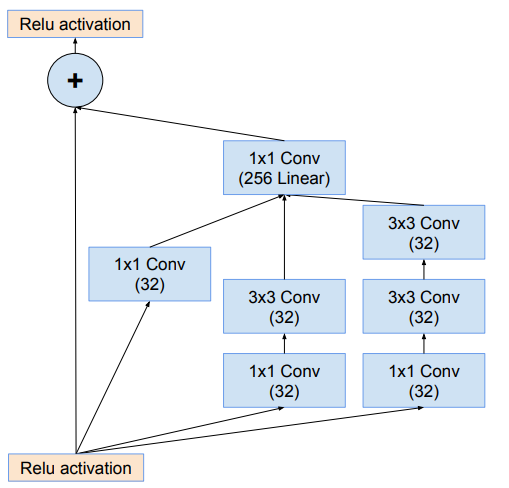

In [6]:
class Inception_resnet_A(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2, c3, c4):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(c1, kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU())
        
        # Branch 2
        self.b2 = nn.Sequential(nn.LazyConv2d(c2[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[1], kernel_size=3, padding = 1), nn.LazyBatchNorm2d(), nn.ReLU())
        
        # Branch 3
        self.b3 = nn.Sequential(nn.LazyConv2d(c3[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c3[1], kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c3[1], kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU())

        self.b4 = nn.Sequential(nn.LazyConv2d(c4, kernel_size=1), nn.LazyBatchNorm2d())
        
    def forward(self, x):
        
        branch1 = self.b1(x)
        branch2 = self.b2(x)
        branch3 = self.b3(x)
        
        y = self.b4(torch.cat((branch1, branch2, branch3), dim=1))
        y += x

        return torch.nn.functional.relu(y)

- Inception-ResNet block B

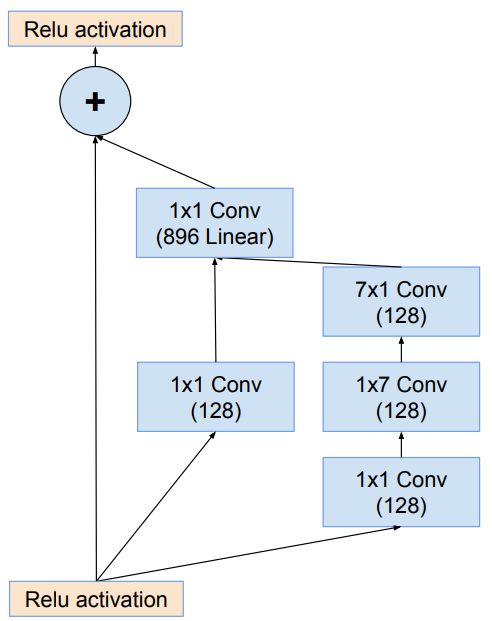

In [7]:
class Inception_resnet_B(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2, c3):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(c1, kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU())
        
        # Branch 2
        self.b2 = nn.Sequential(nn.LazyConv2d(c2[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[1], kernel_size=(1,7), padding=(0,3)), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[1], kernel_size=(7,1), padding=(3,0)), nn.LazyBatchNorm2d(), nn.ReLU())
        
        self.b4 = nn.Sequential(nn.LazyConv2d(c3, kernel_size=1), nn.LazyBatchNorm2d())
        
    def forward(self, x):
        
        branch1 = self.b1(x)
        branch2 = self.b2(x)
 
        y = self.b4(torch.cat((branch1, branch2), dim=1))
        y += x

        return torch.nn.functional.relu(y)

- Inception-ResNet block C

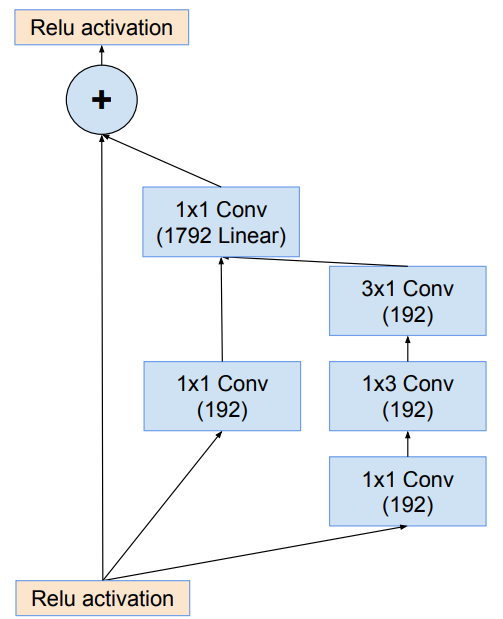

In [8]:
class Inception_resnet_C(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2, c3):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(c1, kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU())
        
        # Branch 2
        self.b2 = nn.Sequential(nn.LazyConv2d(c2[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[1], kernel_size=(1,3), padding=(0,1)), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[1], kernel_size=(3,1), padding=(1,0)), nn.LazyBatchNorm2d(), nn.ReLU())
        
        self.b4 = nn.Sequential(nn.LazyConv2d(c3, kernel_size=1), nn.LazyBatchNorm2d())
        
    def forward(self, x):
        
        branch1 = self.b1(x)
        branch2 = self.b2(x)
 
        y = self.b4(torch.cat((branch1, branch2), dim=1))
        y += x

        return torch.nn.functional.relu(y)

- Reduction block A ($k = 192, l = 192, m = 256, n = 384$)

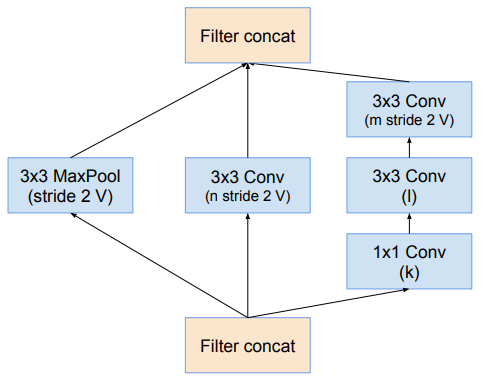

In [9]:
class Inception_resnet_A_red(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(c1, kernel_size=3, padding=1, stride = 2), nn.LazyBatchNorm2d(), nn.ReLU())
        
        # Branch 2
        self.b2 = nn.Sequential(nn.LazyConv2d(c2[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[1], kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[2], kernel_size=3, padding=1, stride = 2), nn.LazyBatchNorm2d(), nn.ReLU())

        # Branch 3
        self.b3 = nn.MaxPool2d(kernel_size=3, stride = 2, padding=1)  
        
    def forward(self, x):
        branch1 = self.b1(x)
        branch2 = self.b2(x)
        branch3 = self.b3(x)

        
        return torch.cat((branch1, branch2, branch3), dim=1)

- Reduction block B 

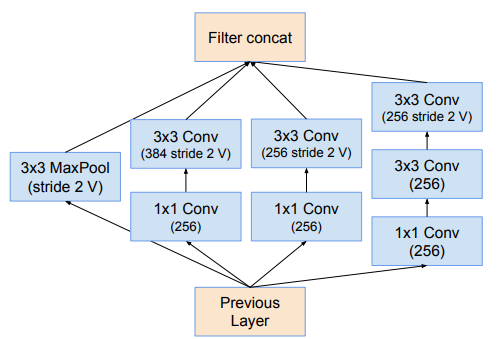

In [10]:
class Inception_resnet_B_red(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2, c3):
        super().__init__()

        # Branch 1
        self.b1 = nn.Sequential(nn.LazyConv2d(c1[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c1[1], kernel_size=3, stride = 2, padding=1), nn.LazyBatchNorm2d(), nn.ReLU())
        
        # Branch 2
        self.b2 = nn.Sequential(nn.LazyConv2d(c2[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c2[1], kernel_size=3, stride = 2, padding=1), nn.LazyBatchNorm2d(), nn.ReLU())
        
        # Branch 3
        self.b3 = nn.Sequential(nn.LazyConv2d(c3[0], kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c3[1], kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU(),
                                nn.LazyConv2d(c3[2], kernel_size=3, stride = 2, padding=1), nn.LazyBatchNorm2d(), nn.ReLU())

        # Branch 4
        self.b4 = nn.Sequential(nn.MaxPool2d(kernel_size=3, stride=2, padding=1))
        
    def forward(self, x):
        branch1 = self.b1(x)
        branch2 = self.b2(x)
        branch3 = self.b3(x)
        branch4 = self.b4(x)
        return torch.cat((branch1, branch2, branch3, branch4), dim=1)

- Stem

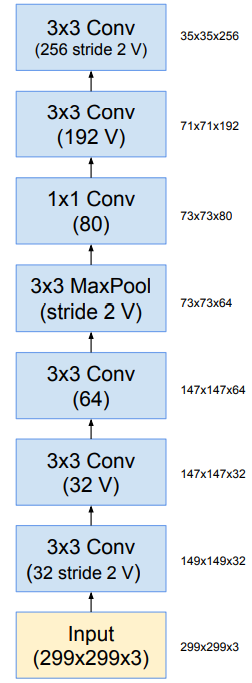

In [11]:
class Inception_resnet_stem(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self):
        super().__init__()


        self.net_stack = nn.Sequential(
            nn.LazyConv2d(32, kernel_size=3, padding=1, stride = 2), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(32, kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(64, kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            nn.LazyConv2d(80, kernel_size=1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(192, kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(256, kernel_size=3, padding=1, stride = 2), nn.LazyBatchNorm2d(), nn.ReLU(),
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

Finally, we can put all these blocks together.

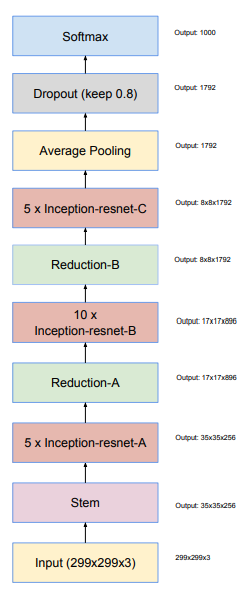

In [12]:
class Inception_resnet_v1(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # stem
        self.stem = Inception_resnet_stem()

        # body block 1
        self.bblock1 =  nn.Sequential(
            Inception_resnet_A(32, (32, 32), (32, 32, 32), 256),
            Inception_resnet_A(32, (32, 32), (32, 32, 32), 256),
            Inception_resnet_A(32, (32, 32), (32, 32, 32), 256),
            Inception_resnet_A(32, (32, 32), (32, 32, 32), 256),
            Inception_resnet_A(32, (32, 32), (32, 32, 32), 256),
            Inception_resnet_A_red(384, (192, 192, 256))
        )

        self.bblock2 =  nn.Sequential(
            Inception_resnet_B(128, (128, 128, 128), 896),
            Inception_resnet_B(128, (128, 128, 128), 896),
            Inception_resnet_B(128, (128, 128, 128), 896),
            Inception_resnet_B(128, (128, 128, 128), 896),
            Inception_resnet_B(128, (128, 128, 128), 896),
            Inception_resnet_B(128, (128, 128, 128), 896),
            Inception_resnet_B(128, (128, 128, 128), 896),
            Inception_resnet_B(128, (128, 128, 128), 896),
            Inception_resnet_B(128, (128, 128, 128), 896),
            Inception_resnet_B(128, (128, 128, 128), 896),
            Inception_resnet_B_red((256,384), (256,256), (256, 256, 256))
        )

        self.bblock3 =  nn.Sequential(
            Inception_resnet_C(192, (192, 192, 192), 1792),
            Inception_resnet_C(192, (192, 192, 192), 1792),
            Inception_resnet_C(192, (192, 192, 192), 1792),
            Inception_resnet_C(192, (192, 192, 192), 1792),
            Inception_resnet_C(192, (192, 192, 192), 1792),
            nn.AdaptiveAvgPool2d((1,1)), nn.Flatten()
        )
        
        self.net_stack = nn.Sequential(
            self.stem, self.bblock1, self.bblock2, self.bblock3,
            nn.Dropout(0.2),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [13]:
layer_summary(Inception_resnet_v1(10),(1, 1, 64, 64))

Inception_resnet_stem output shape:	 torch.Size([1, 256, 8, 8])
Sequential output shape:	 torch.Size([1, 896, 4, 4])
Sequential output shape:	 torch.Size([1, 1792, 2, 2])
Sequential output shape:	 torch.Size([1, 1792])
Dropout output shape:	 torch.Size([1, 1792])
Linear output shape:	 torch.Size([1, 10])


Let us demonstrate Inception-ResNet V1 on upscaled images of the Fashion-MNIST dataset [[4](#4)].

In [14]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [64, 64], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([64,64]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)  


# inception initialization
Inception_resnet_cuda = Inception_resnet_v1(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
Inception_resnet_cuda(x);
Inception_resnet_cuda.apply(init_weights_he);

optim_SGD_cuda =  torch.optim.SGD(Inception_resnet_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[35], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, Inception_resnet_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

2383.066679239273


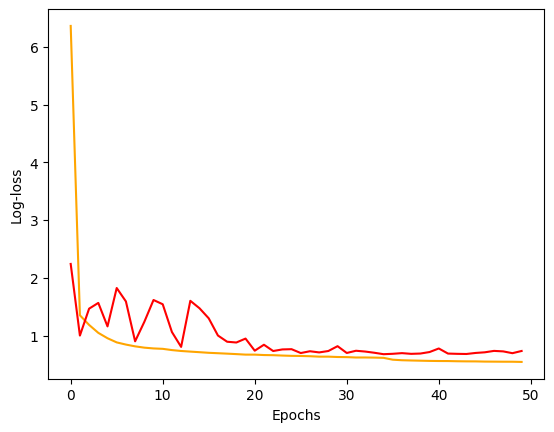

In [15]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

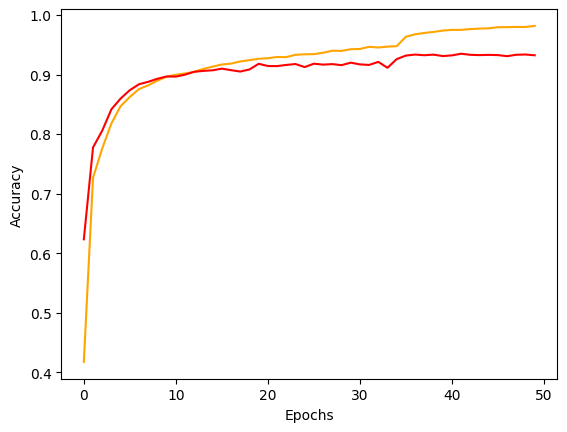

In [16]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

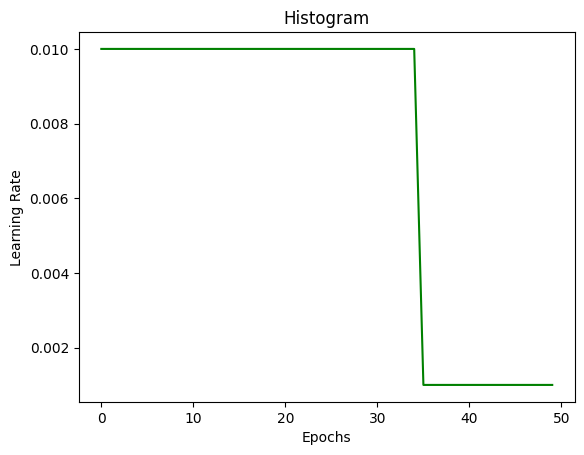

In [17]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [18]:
accu_epochs_train[49]

0.9815833568572998

In [19]:
accu_epochs_test[49]

0.9322999715805054

In [20]:
accu_epochs_test.max()

0.9348999857902527

The Inception-ResNet performed reasonably well. Next, let us try to downscale the model to better fit the Fashion-MNIST dataset.

In [21]:
class Inception_resnet_stem_red(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self):
        super().__init__()


        self.net_stack = nn.Sequential(
            nn.LazyConv2d(32, kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(64, kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.LazyConv2d(128, kernel_size=3, padding=1), nn.LazyBatchNorm2d(), nn.ReLU(),              
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [22]:
class Inception_resnet_v1_red(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # stem
        self.stem = Inception_resnet_stem_red()

        # body block 1
        self.bblock1 =  nn.Sequential(
            Inception_resnet_A(32, (32, 32), (32, 32, 32), 128),
            Inception_resnet_A(32, (32, 32), (32, 32, 32), 128),
            Inception_resnet_A(32, (32, 32), (32, 32, 32), 128),
            Inception_resnet_A(32, (32, 32), (32, 32, 32), 128),
            Inception_resnet_A(32, (32, 32), (32, 32, 32), 128),
            Inception_resnet_A_red(128, (96, 96, 128))
        )

        self.bblock2 =  nn.Sequential(
            Inception_resnet_B(64, (64, 64, 64), 384),
            Inception_resnet_B(64, (64, 64, 64), 384),
            Inception_resnet_B(64, (64, 64, 64), 384),
            Inception_resnet_B(64, (64, 64, 64), 384),
            Inception_resnet_B(64, (64, 64, 64), 384),
            Inception_resnet_B(64, (64, 64, 64), 384),
            Inception_resnet_B(64, (64, 64, 64), 384),
            Inception_resnet_B(64, (64, 64, 64), 384),
            Inception_resnet_B(64, (64, 64, 64), 384),
            Inception_resnet_B(64, (64, 64, 64), 384),
            Inception_resnet_B_red((128,256), (128,128), (128, 128, 128))
        )

        self.bblock3 =  nn.Sequential(
            Inception_resnet_C(128, (128, 128, 128), 896),
            Inception_resnet_C(128, (128, 128, 128), 896),
            Inception_resnet_C(128, (128, 128, 128), 896),
            Inception_resnet_C(128, (128, 128, 128), 896),
            Inception_resnet_C(128, (128, 128, 128), 896),
            nn.AdaptiveAvgPool2d((1,1)), nn.Flatten()
        )
        
        self.net_stack = nn.Sequential(
            self.stem, self.bblock1, self.bblock2, self.bblock3,
            nn.Dropout(0.2),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [23]:
layer_summary(Inception_resnet_v1_red(10),(1, 1, 28, 28))

Inception_resnet_stem_red output shape:	 torch.Size([1, 128, 14, 14])
Sequential output shape:	 torch.Size([1, 384, 7, 7])
Sequential output shape:	 torch.Size([1, 896, 4, 4])
Sequential output shape:	 torch.Size([1, 896])
Dropout output shape:	 torch.Size([1, 896])
Linear output shape:	 torch.Size([1, 10])


In [24]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [28, 28], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([28,28]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)  


# initialization
Inception_resnet_cuda = Inception_resnet_v1_red(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
Inception_resnet_cuda(x);
Inception_resnet_cuda.apply(init_weights_he);


optim_SGD_cuda =  torch.optim.SGD(Inception_resnet_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[35], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, Inception_resnet_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

2172.127860546112


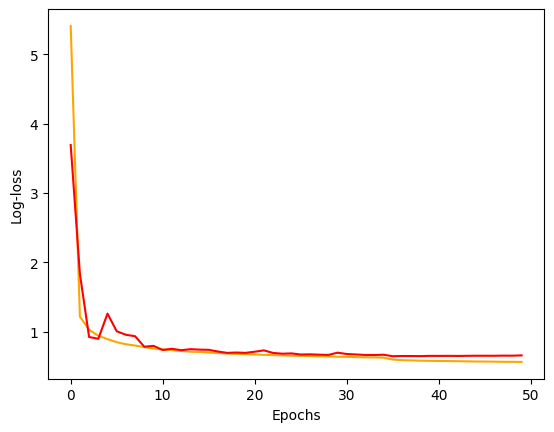

In [25]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

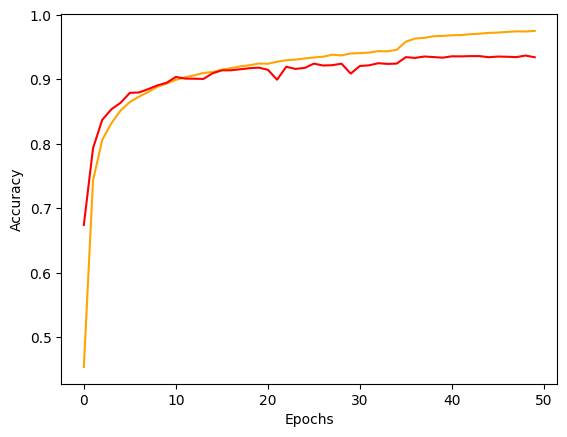

In [26]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

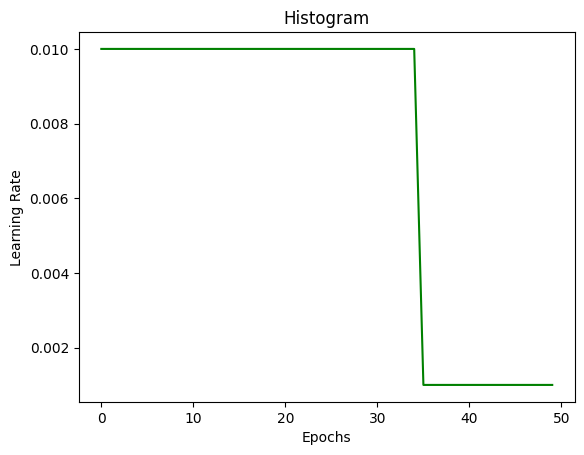

In [27]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [28]:
accu_epochs_train[49]

0.9754000306129456

In [29]:
accu_epochs_test[49]

0.934499979019165

In [30]:
accu_epochs_test.max()

0.9371999502182007

This is a pretty good performance. The CIFAR-10 dataset is next (https://www.cs.toronto.edu/~kriz/cifar.html).

In [31]:
torch.manual_seed(123)

transforms_cifar10_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size=[32,32], scale = [0.8, 1.4]),
    ]
)

transforms_cifar10_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10_train)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10_test)


cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 250, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 250, shuffle = False)

# inception initialization
Inception_resnet_cuda = Inception_resnet_v1_red(10).to(cuda_device)

x = (cifar10_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
Inception_resnet_cuda(x);
Inception_resnet_cuda.apply(init_weights_he);

optim_SGD_cuda =  torch.optim.SGD(Inception_resnet_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[60, 85], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)
n_epochs = 100

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]  = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, Inception_resnet_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

3893.5808069705963


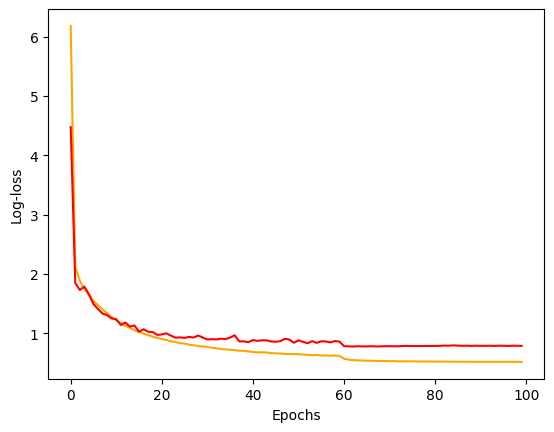

In [32]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

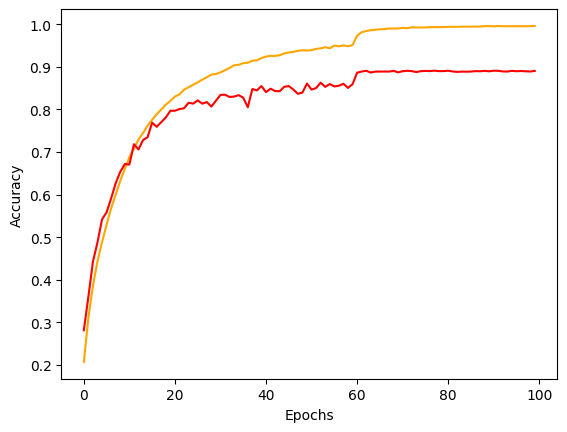

In [33]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

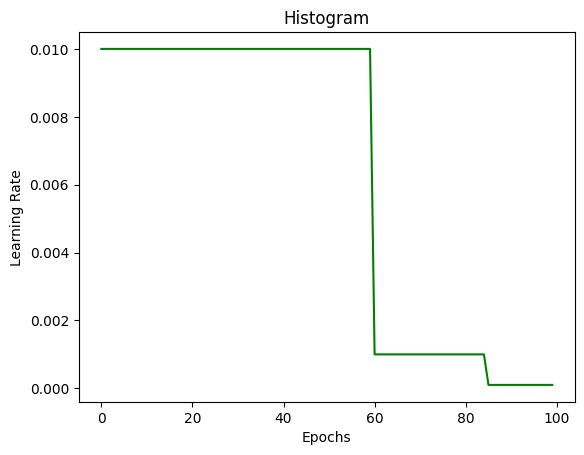

In [34]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [35]:
accu_epochs_train[49]

0.9382799863815308

In [36]:
accu_epochs_test[49]

0.8607999682426453

In [37]:
accu_epochs_test.max()

0.890999972820282

Unfortunately, this performance is not so great. We would have to tweak our Inception-ResNet model a bit more.

## ResNeXt <a class="anchor" id="resnext"></a>

The second network architecture we will introduce in this project is ResNext [[3](#3)]. ResNeXt is a continuation of Inception in the sense of using blocks with multiple branches. However, unlike Inception, the branches in the ResNeXt block are all identical. The resulting operation is known as a *group convolution*, and its main advantage over the usual convolution is a much lower number of parameters: the convolution kernel in each group is applied only to a limited number of channels that belong to its group instead of all of them. This is an important observation used in later convolutional neural networks designed for smaller devices (i.e., mobile phones) with limited memory.

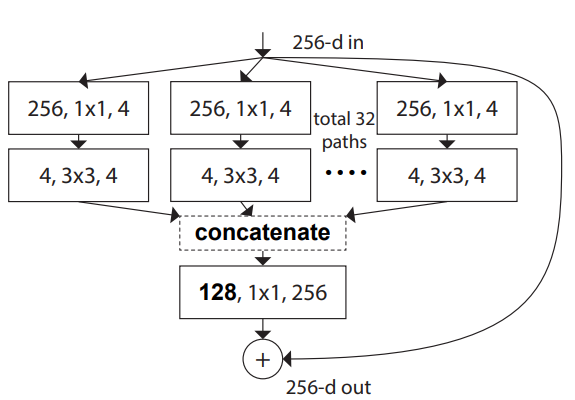

In [38]:
class ResNeXtBlock(nn.Module): 

    def __init__(self, num_ouput_channels, group_channels_total, num_groups, conv1x1 = False, strides = 1):
        super().__init__()

        self.conv1 = nn.LazyConv2d(group_channels_total, kernel_size=1, stride=1)
        self.conv2 = nn.LazyConv2d(group_channels_total, kernel_size=3, stride=strides, padding=1, groups = num_groups)
        self.conv3 = nn.LazyConv2d(num_ouput_channels, kernel_size=1, stride=1)
    
        self.bn1 = nn.LazyBatchNorm2d()
        self.bn2 = nn.LazyBatchNorm2d()
        self.bn3 = nn.LazyBatchNorm2d()
    
        if conv1x1:
            self.conv4 = nn.LazyConv2d(num_ouput_channels, kernel_size=1, stride=strides)
            self.bn4 = nn.LazyBatchNorm2d()
        else:
            self.conv4 = None
        
    def forward(self, X):
        Y = torch.nn.functional.relu(self.bn1(self.conv1(X)))
        Y = torch.nn.functional.relu(self.bn2(self.conv2(Y)))
        Y = self.bn3(self.conv3(Y))
        
        if self.conv4:
            X = self.bn4(self.conv4(X))
            
        return torch.nn.functional.relu(Y + X)

We will implement ResNeXt-50 using the following table from [[3](#3)].

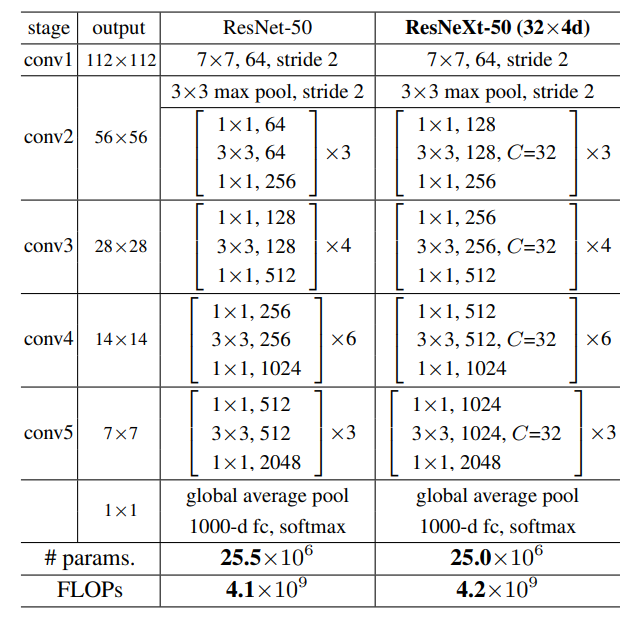

In [39]:
class ResNeXt_50(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

         # block 1
        self.b1 = nn.Sequential(
            nn.LazyConv2d(64, kernel_size=7, stride=2, padding=3),  nn.LazyBatchNorm2d(), nn.ReLU(), 
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        
        # residual blocks
        self.b2 =  nn.Sequential(
            ResNeXtBlock(256, 128, 32, conv1x1 = True),
            ResNeXtBlock(256, 128, 32),
            ResNeXtBlock(256, 128, 32),
            ResNeXtBlock(512, 256, 32, strides = 2, conv1x1 = True),
            ResNeXtBlock(512, 256, 32),
            ResNeXtBlock(512, 256, 32),
            ResNeXtBlock(512, 256, 32),
            ResNeXtBlock(1024, 512, 32, strides = 2, conv1x1 = True),
            ResNeXtBlock(1024, 512, 32),
            ResNeXtBlock(1024, 512, 32),
            ResNeXtBlock(1024, 512, 32),
            ResNeXtBlock(1024, 512, 32),
            ResNeXtBlock(1024, 512, 32),
            ResNeXtBlock(2048, 1024, 32, strides = 2, conv1x1 = True),
            ResNeXtBlock(2048, 1024, 32),
            ResNeXtBlock(2048, 1024, 32),
        )

        self.net_stack = nn.Sequential(
            self.b1, self.b2,  nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [40]:
layer_summary(ResNeXt_50(10),(1, 1, 64, 64))

Sequential output shape:	 torch.Size([1, 64, 16, 16])
Sequential output shape:	 torch.Size([1, 2048, 2, 2])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 2048, 1, 1])
Flatten output shape:	 torch.Size([1, 2048])
Linear output shape:	 torch.Size([1, 10])


Again, we will first evaluate the performance on the upscaled Fashion-MNIST dataset.

In [41]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [64, 64], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([64,64]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)  


# resnext initialization
ResNeXt_cuda = ResNeXt_50(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
ResNeXt_cuda(x);
ResNeXt_cuda.apply(init_weights_he);

In [42]:
sum(p.numel() for p in ResNeXt_cuda.parameters() if p.requires_grad)

23028234

In [43]:
optim_SGD_cuda =  torch.optim.SGD(ResNeXt_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[35], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, ResNeXt_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

2299.270679950714


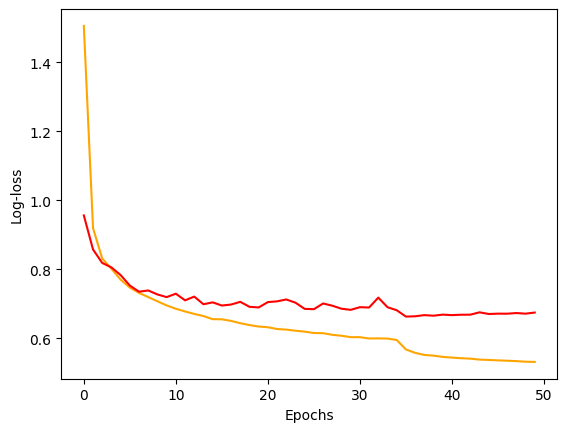

In [44]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

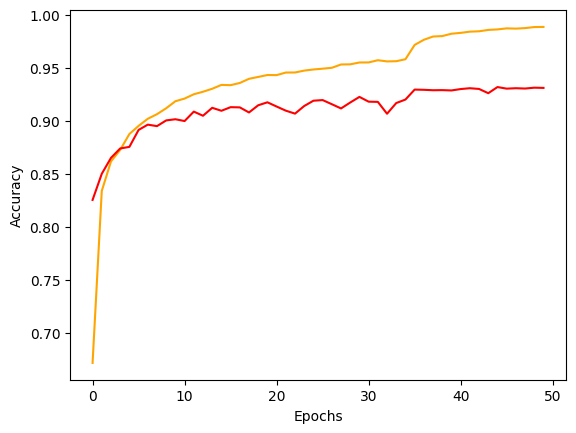

In [45]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

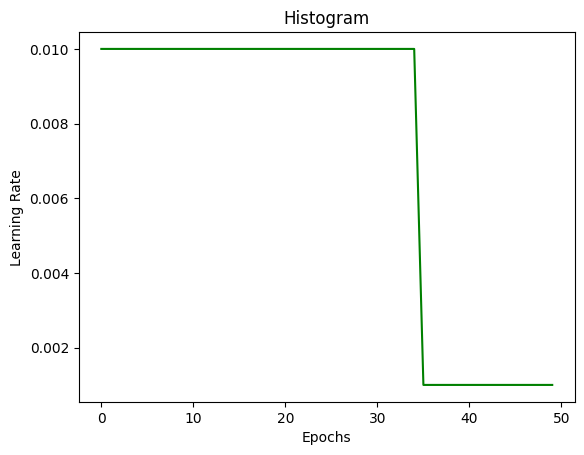

In [46]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [47]:
accu_epochs_train[49]

0.9885833263397217

In [48]:
accu_epochs_test[49]

0.9309999942779541

In [49]:
accu_epochs_test.max()

0.9317999482154846

From the get-go, we have obtained a decent performance. Let us again slightly modify the model for the original-sized images.

In [50]:
class ResNeXt_50_red(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

         # block 1
        self.b1 = nn.Sequential(
            nn.LazyConv2d(64, kernel_size=3, stride=1, padding=1),  nn.LazyBatchNorm2d(), nn.ReLU(), 
        )
        
        # residual blocks
        self.b2 =  nn.Sequential(
            ResNeXtBlock(512, 4*16, 4, conv1x1 = True),
            ResNeXtBlock(512, 4*16, 4),
            ResNeXtBlock(512, 4*16, 4),
            ResNeXtBlock(1024, 4*32, 4, strides = 2, conv1x1 = True),
            ResNeXtBlock(1024, 4*32, 4),
            ResNeXtBlock(1024, 4*32, 4),
            ResNeXtBlock(2048, 4*64, 4, strides = 2, conv1x1 = True),
            ResNeXtBlock(2048, 4*64, 4),
            ResNeXtBlock(2048, 4*64, 4)
        )

        self.net_stack = nn.Sequential(
            self.b1, self.b2,  nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [51]:
layer_summary(ResNeXt_50_red(10),(1, 1, 32, 32))

Sequential output shape:	 torch.Size([1, 64, 32, 32])
Sequential output shape:	 torch.Size([1, 2048, 8, 8])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 2048, 1, 1])
Flatten output shape:	 torch.Size([1, 2048])
Linear output shape:	 torch.Size([1, 10])


In [52]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [28, 28], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)  


# resnext initialization
ResNeXt_cuda = ResNeXt_50_red(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
ResNeXt_cuda(x);
ResNeXt_cuda.apply(init_weights_he);

In [53]:
optim_SGD_cuda =  torch.optim.SGD(ResNeXt_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[35], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, ResNeXt_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

2893.657595396042


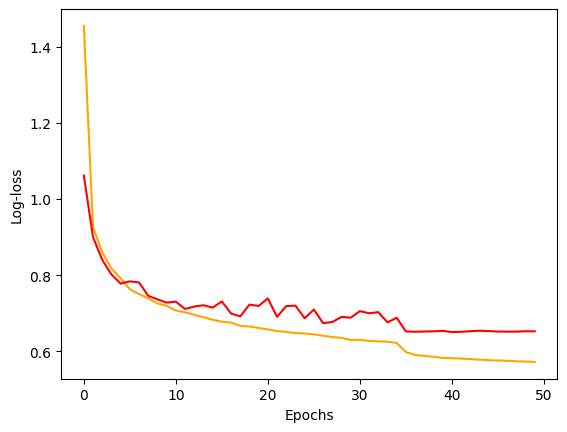

In [54]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

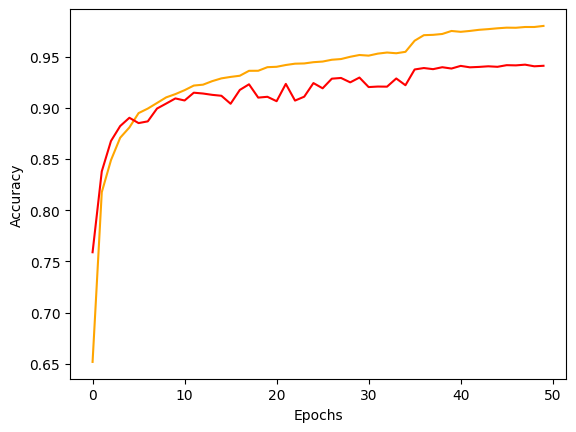

In [55]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

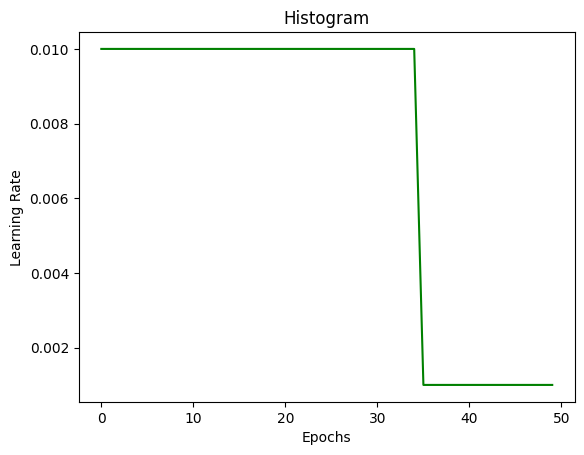

In [56]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [57]:
accu_epochs_train[49]

0.9800500273704529

In [58]:
accu_epochs_test[49]

0.941100001335144

In [59]:
accu_epochs_test.max()

0.9422000050544739

We managed to improve the perfromance by about 1% (although, we did not exceed 95% accuracy by ResNet). Let us also check the CIFAR-10 dataset.

In [60]:
torch.manual_seed(123)

transforms_cifar10_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size=[32,32], scale = [0.8, 1.4]),
    ]
)

transforms_cifar10_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10_train)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10_test)


cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 125, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 125, shuffle = False)

# resnext initialization
ResNeXt_cuda = ResNeXt_50_red(10).to(cuda_device)

x = (cifar10_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
ResNeXt_cuda(x);
ResNeXt_cuda.apply(init_weights_he);

In [61]:
optim_SGD_cuda =  torch.optim.SGD(ResNeXt_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[60, 85], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 100

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]  = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, ResNeXt_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

6030.339949607849


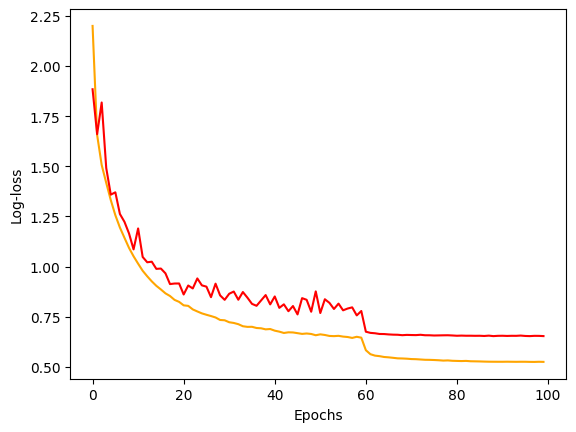

In [62]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

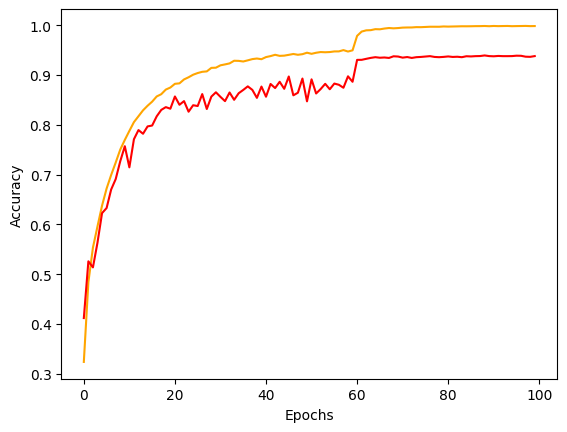

In [63]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

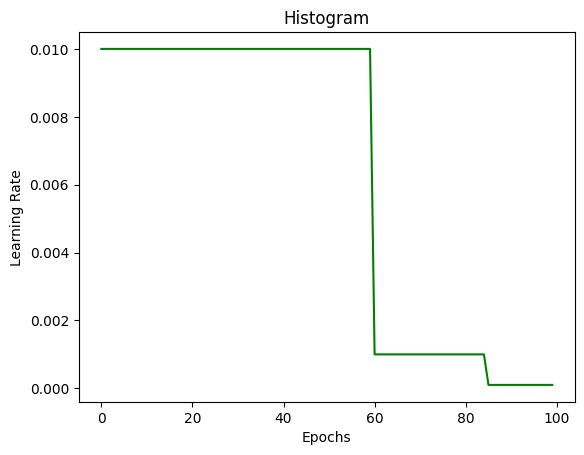

In [64]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [65]:
accu_epochs_train[99]

0.9984399676322937

In [66]:
accu_epochs_test[99]

0.9380999803543091

In [67]:
accu_epochs_test.max()

0.9393999576568604

We matched our ResNet performance.

## References <a class="anchor" id="references"></a>

<a id="1">[1]</a> HE, Kaiming, et al. Deep residual learning for image recognition. In: Proceedings of the IEEE conference on computer vision and pattern recognition. 2016. p. 770-778.

<a id="2">[2]</a> SZEGEDY, Christian, et al. Inception-v4, inception-resnet and the impact of residual connections on learning. In: *Proceedings of the AAAI conference on artificial intelligence.* 2017.

<a id="3">[3]</a> XIE, Saining, et al. Aggregated residual transformations for deep neural networks. In: *Proceedings of the IEEE conference on computer vision and pattern recognition*. 2017. p. 1492-1500.

<a id="4">[4]</a> XIAO, Han; RASUL, Kashif; VOLLGRAF, Roland. Fashion-mnist: a novel image dataset for benchmarking machine learning algorithms. arXiv preprint arXiv:1708.07747, 2017.